In [1]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime as dt
from scipy.stats import chi2_contingency

In [ ]:
# load data
df_cleaned = pl.read_parquet("data/cleaned.parquet")

In [ ]:
df_cleaned.head(3)

timestamp,source.ip,source.registered_domain,source.as,source.geo,destination.ip,http.request.method,http.response.status_code,http.response.bytes,url.path,url.filetype,user_agent.name,user_agent.version,user_agent.os.platform,user_agent.os.device.name,user_agent.category,agent.name,agent.id,tags,correlation,geo_code
datetime[ms],str,str,struct[2],struct[4],str,str,str,i64,str,str,str,str,str,str,str,str,str,list[str],struct[1],str
2020-12-21 09:29:52,"""93.94.228.141""","""egis.cyso.net""","{""Cyso Group B.V."",25151}","{{52.6318,4.7409},""Alkmaar"",""Netherlands"",""NL""}","""116.203.157.62""","""GET""","""200""",4304,"""/v2/securely/front-end/securel…","""develop""","""Go-http-client""","""1""","""Other""","""Other""","""SCRIPTING""","""gitlab""","""ad99edda-a068-4794-b2c5-201664…","[""beats_input_codec_plain_applied"", ""exclusion-exclude-on-unknown-user-agent-is-used-to-perform-request--1580584312"", ""file_backup""]","{[""customer-onprem""]}","""NL"""
2020-12-21 09:29:52,"""93.94.228.141""","""egis.cyso.net""","{""Cyso Group B.V."",25151}","{{52.6318,4.7409},""Alkmaar"",""Netherlands"",""NL""}","""116.203.157.62""","""GET""","""200""",4929,"""/v2/logstash/logstash-config/m…","""latest""","""Go-http-client""","""1""","""Other""","""Other""","""SCRIPTING""","""gitlab""","""ad99edda-a068-4794-b2c5-201664…","[""beats_input_codec_plain_applied"", ""exclusion-exclude-on-unknown-user-agent-is-used-to-perform-request--1580584312"", ""file_backup""]","{[""customer-onprem""]}","""NL"""
2020-12-21 09:29:53,"""84.207.227.190""",null,"{""euNetworks GmbH"",13237}","{{52.3759,4.8975},""Amsterdam"",""Netherlands"",""NL""}","""116.203.157.62""","""GET""","""200""",4929,"""/v2/logstash/logstash-config/m…","""6-add-support-for-palo-alto-fr…","""Go-http-client""","""1""","""Other""","""Other""","""SCRIPTING""","""gitlab""","""ad99edda-a068-4794-b2c5-201664…","[""beats_input_codec_plain_applied"", ""exclusion-exclude-on-unknown-user-agent-is-used-to-perform-request--1580584312"", ""file_backup""]","{[""customer-onprem""]}","""NL"""


In [ ]:
daily_counts = (
    df_cleaned.group_by(
        # Extract the full date (YYYY-MM-DD)
        pl.col("timestamp").dt.date().alias("date")
    )
    .len() 
    .sort("date")
)

print(daily_counts)

shape: (7, 2)
┌────────────┬────────┐
│ date       ┆ len    │
│ ---        ┆ ---    │
│ date       ┆ u32    │
╞════════════╪════════╡
│ 2020-12-21 ┆ 101594 │
│ 2020-12-22 ┆ 106777 │
│ 2020-12-23 ┆ 102568 │
│ 2020-12-24 ┆ 99776  │
│ 2020-12-25 ┆ 93493  │
│ 2020-12-26 ┆ 94011  │
│ 2020-12-27 ┆ 93286  │
└────────────┴────────┘


In [ ]:
# Aggregating by day to for plots
df_agg = (
    df_cleaned.group_by(
        pl.col("timestamp").dt.date().cast(pl.String).alias("day"),
        pl.col("timestamp").dt.truncate("5m").dt.time().alias("time_bin")
    )
    .len()  # Get the count of requests
    .sort("day", "time_bin") # Sort for a clean line plot
)

In [ ]:
def print_traffic_for_days(df_agg, days=[21,22,23,24,25,26,27]):
    df_pd = df_agg.to_pandas()
    dummy_date = dt.date(dt.now())
    df_pd['plot_time'] = df_pd['time_bin'].apply(lambda t: dt.combine(dummy_date, t))

    # Filter to only show day 24

    date_str = '2020-12-'
    filter = []
    for day in days:
        filter.append(f"{date_str}{day:02d}")
    df_pd = df_pd[df_pd['day'].isin(filter)]

    g = sns.FacetGrid(
        df_pd, 
        col="day", 
        col_wrap=4,  
        height=4,   
        aspect=1.5   
    )

    g.map(sns.lineplot, "plot_time", "len", color="navy", linewidth=1.5)

    g.map(plt.axhline, y=340, color='red', linestyle='--', linewidth=2)

    g.set_titles(col_template="{col_name}", size=14)
    g.set_axis_labels("Time of Day", "Number of Requests")


    for ax in g.axes.flat:
        # Set the x-axis formatter and locator
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=4)) # Ticks every 4 hours
        
        # Add gridlines
        ax.grid(axis='both', linestyle='--', alpha=0.6)


    plt.suptitle('Requests per 5-Minute Interval (by Day)', fontsize=18, y=1.03)
    plt.tight_layout()


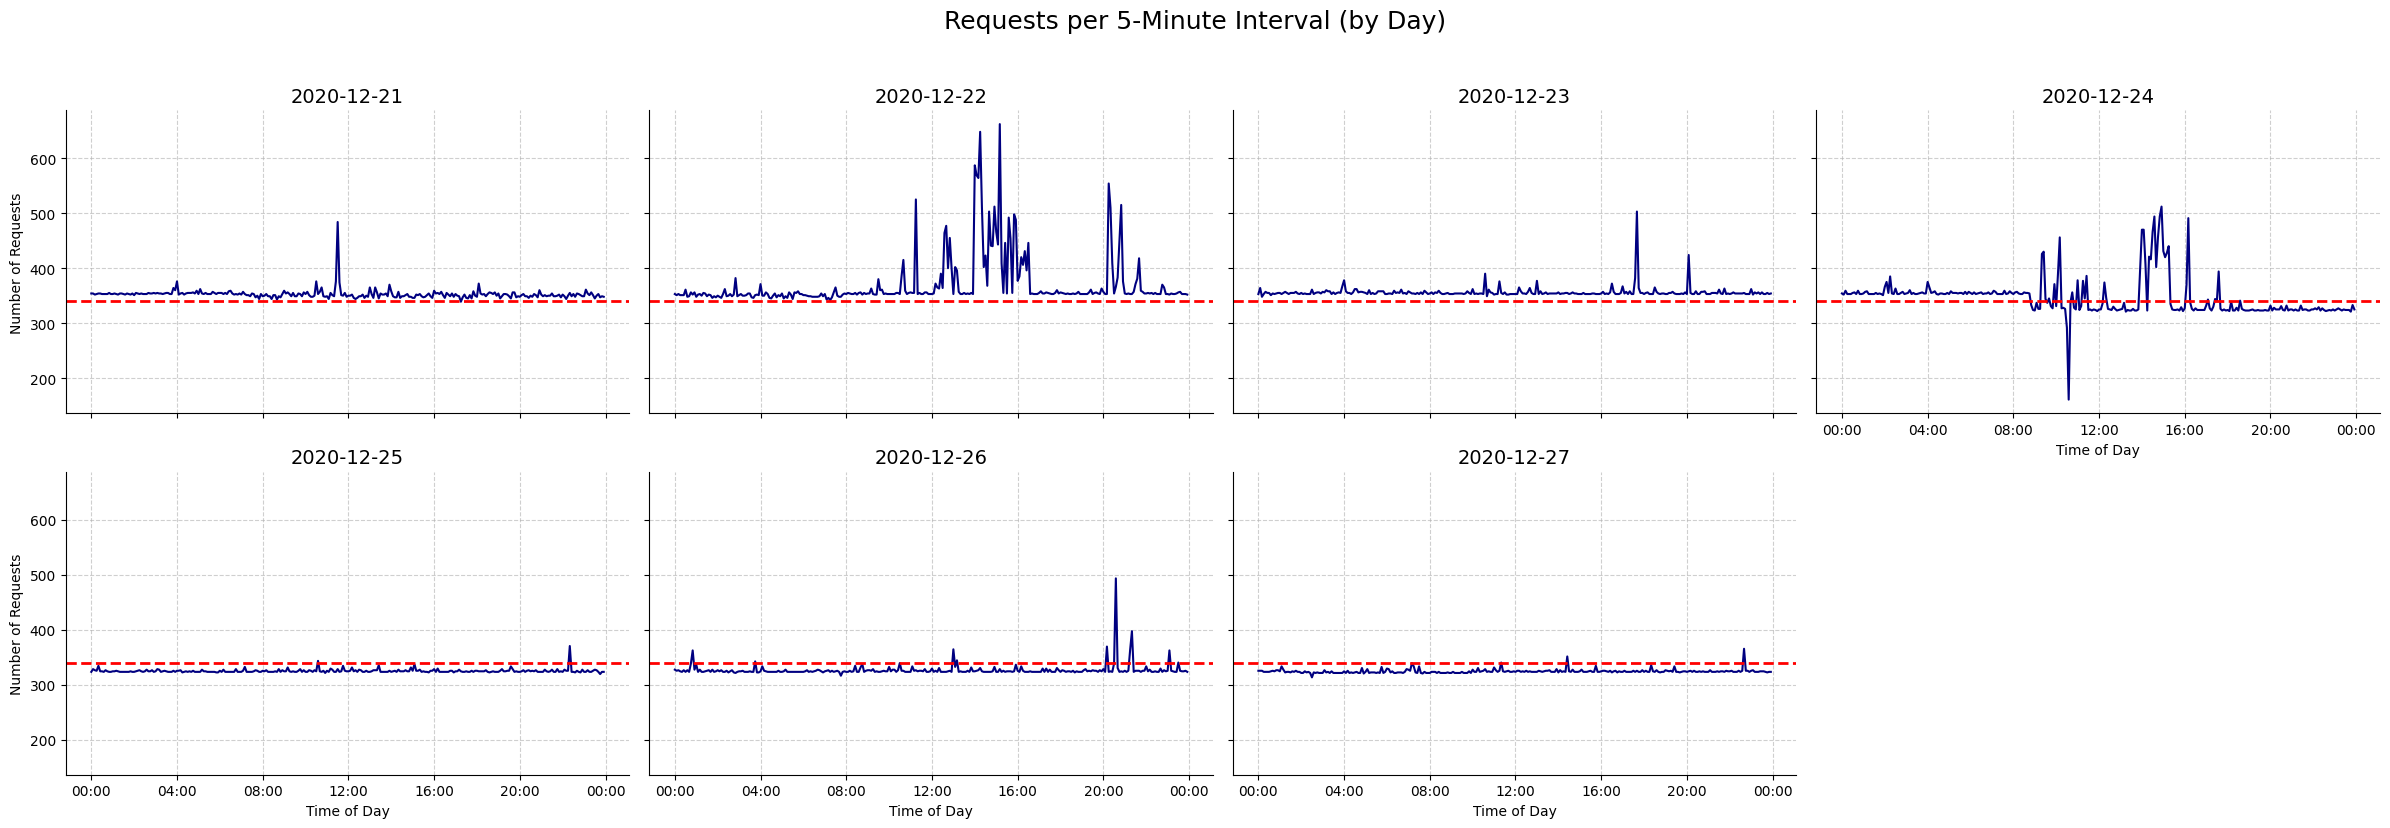

In [ ]:
days = [d for d in range(21, 28)]
print_traffic_for_days(df_agg, days)

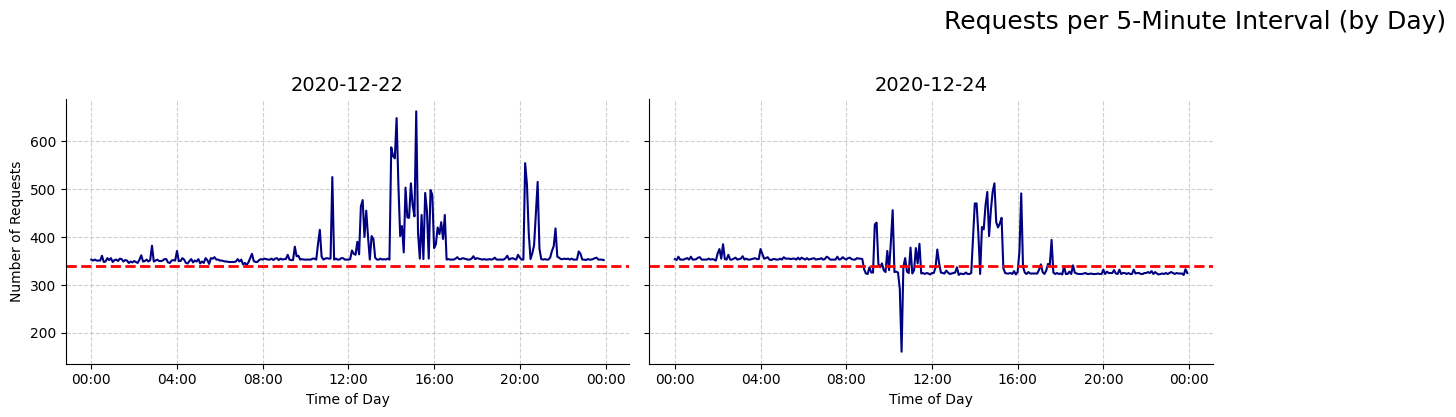

In [ ]:
days = [22, 24]
print_traffic_for_days(df_agg, days)
# Possible attacks 22, 24

In [ ]:
low_traffic_bins = df_agg.filter(
    pl.col("len") < 300
)
low_traffic_bins
# possible attack 24 - servers down

day,time_bin,len
str,time,u32
"""2020-12-24""",10:30:00,292
"""2020-12-24""",10:35:00,161


In [ ]:
requests_per_ip = df_cleaned.group_by("source.ip").agg(
    pl.len().alias("request_count")).sort("request_count", descending=True)

mean_cnt = requests_per_ip["request_count"].mean()
sus_ip_cnt = requests_per_ip.filter(
    pl.col("request_count") > mean_cnt
    )
suspected_ip = sus_ip_cnt["source.ip"]

In [ ]:
# Aggregating by day to for plots
df_agg_sus = (
    df_cleaned
    .filter(pl.col("source.ip").is_in(suspected_ip))
    .group_by(
        pl.col("timestamp").dt.date().cast(pl.String).alias("day"),
        pl.col("timestamp").dt.truncate("5m").dt.time().alias("time_bin")
    )
    .len()  # Get the count of requests
    .sort("day", "time_bin") # Sort for a clean line plot
)

C:\Users\wojom\AppData\Local\Temp\ipykernel_25436\2144196755.py:4: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(pl.col("source.ip").is_in(suspected_ip))


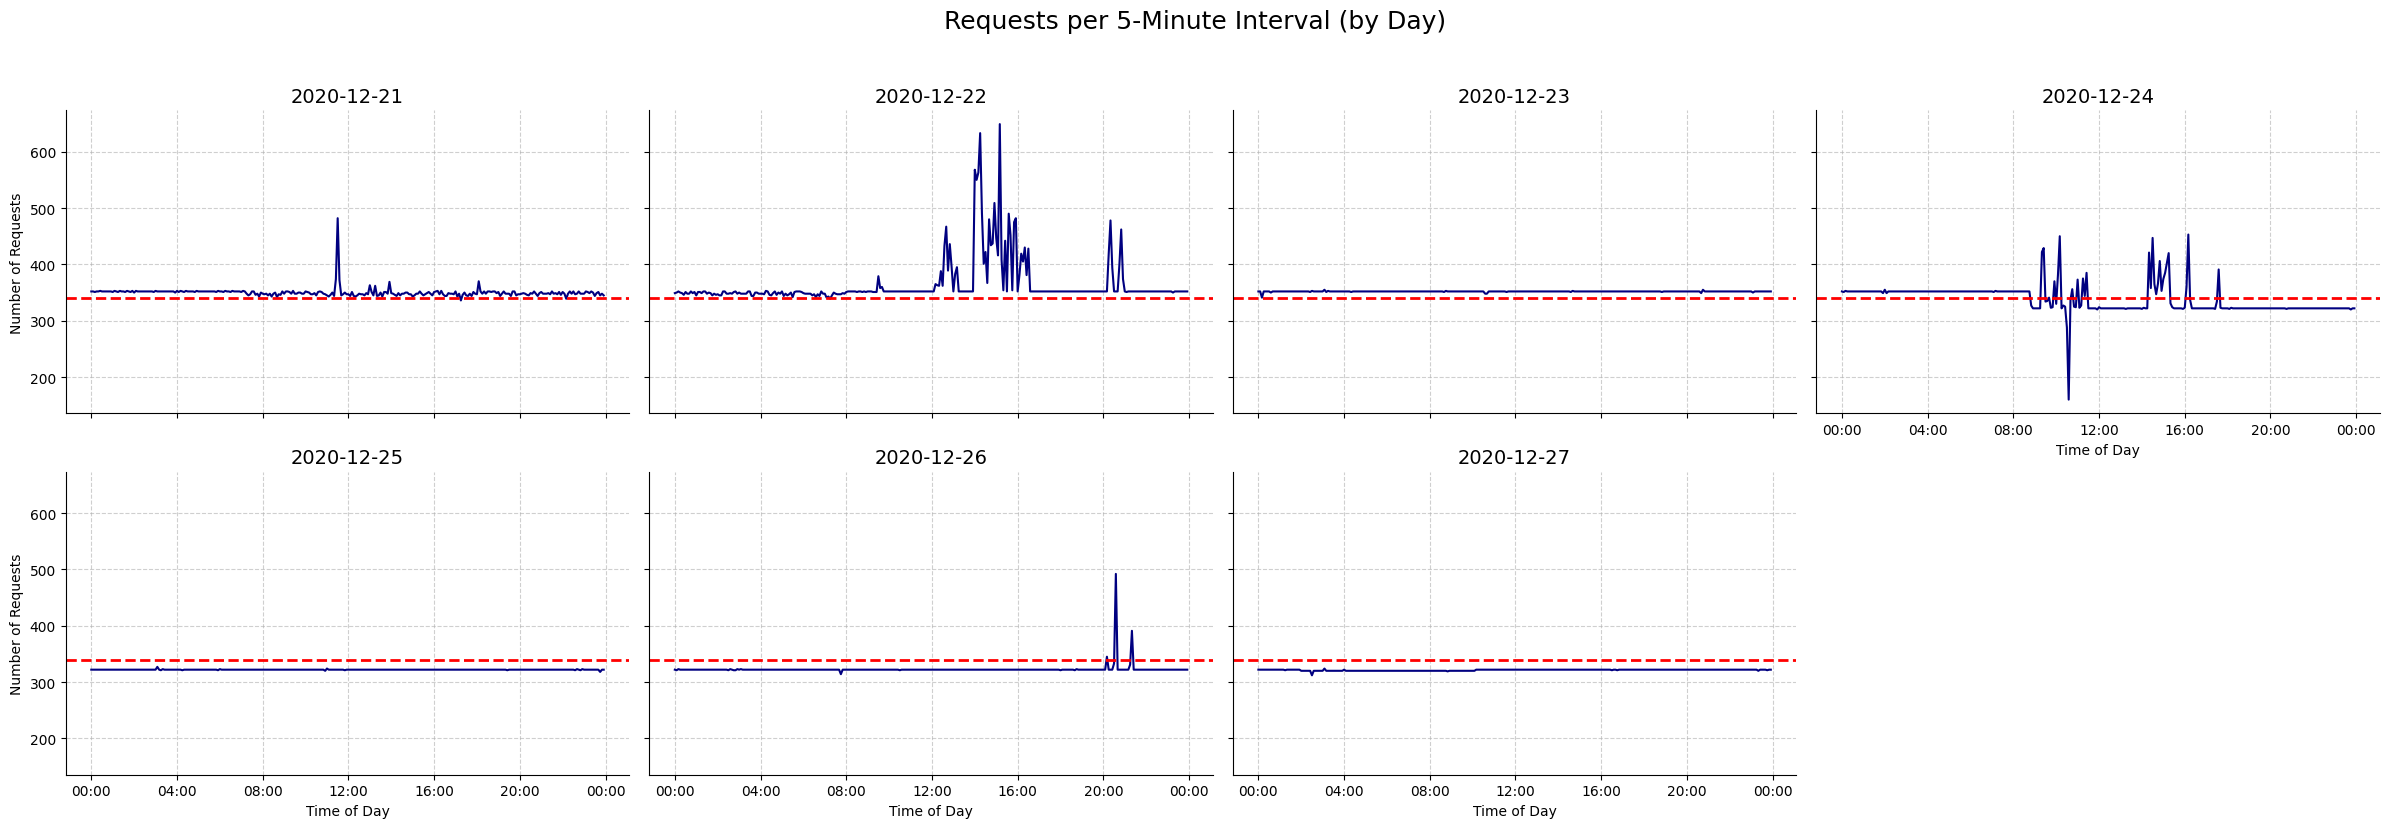

In [ ]:
print_traffic_for_days(df_agg_sus)

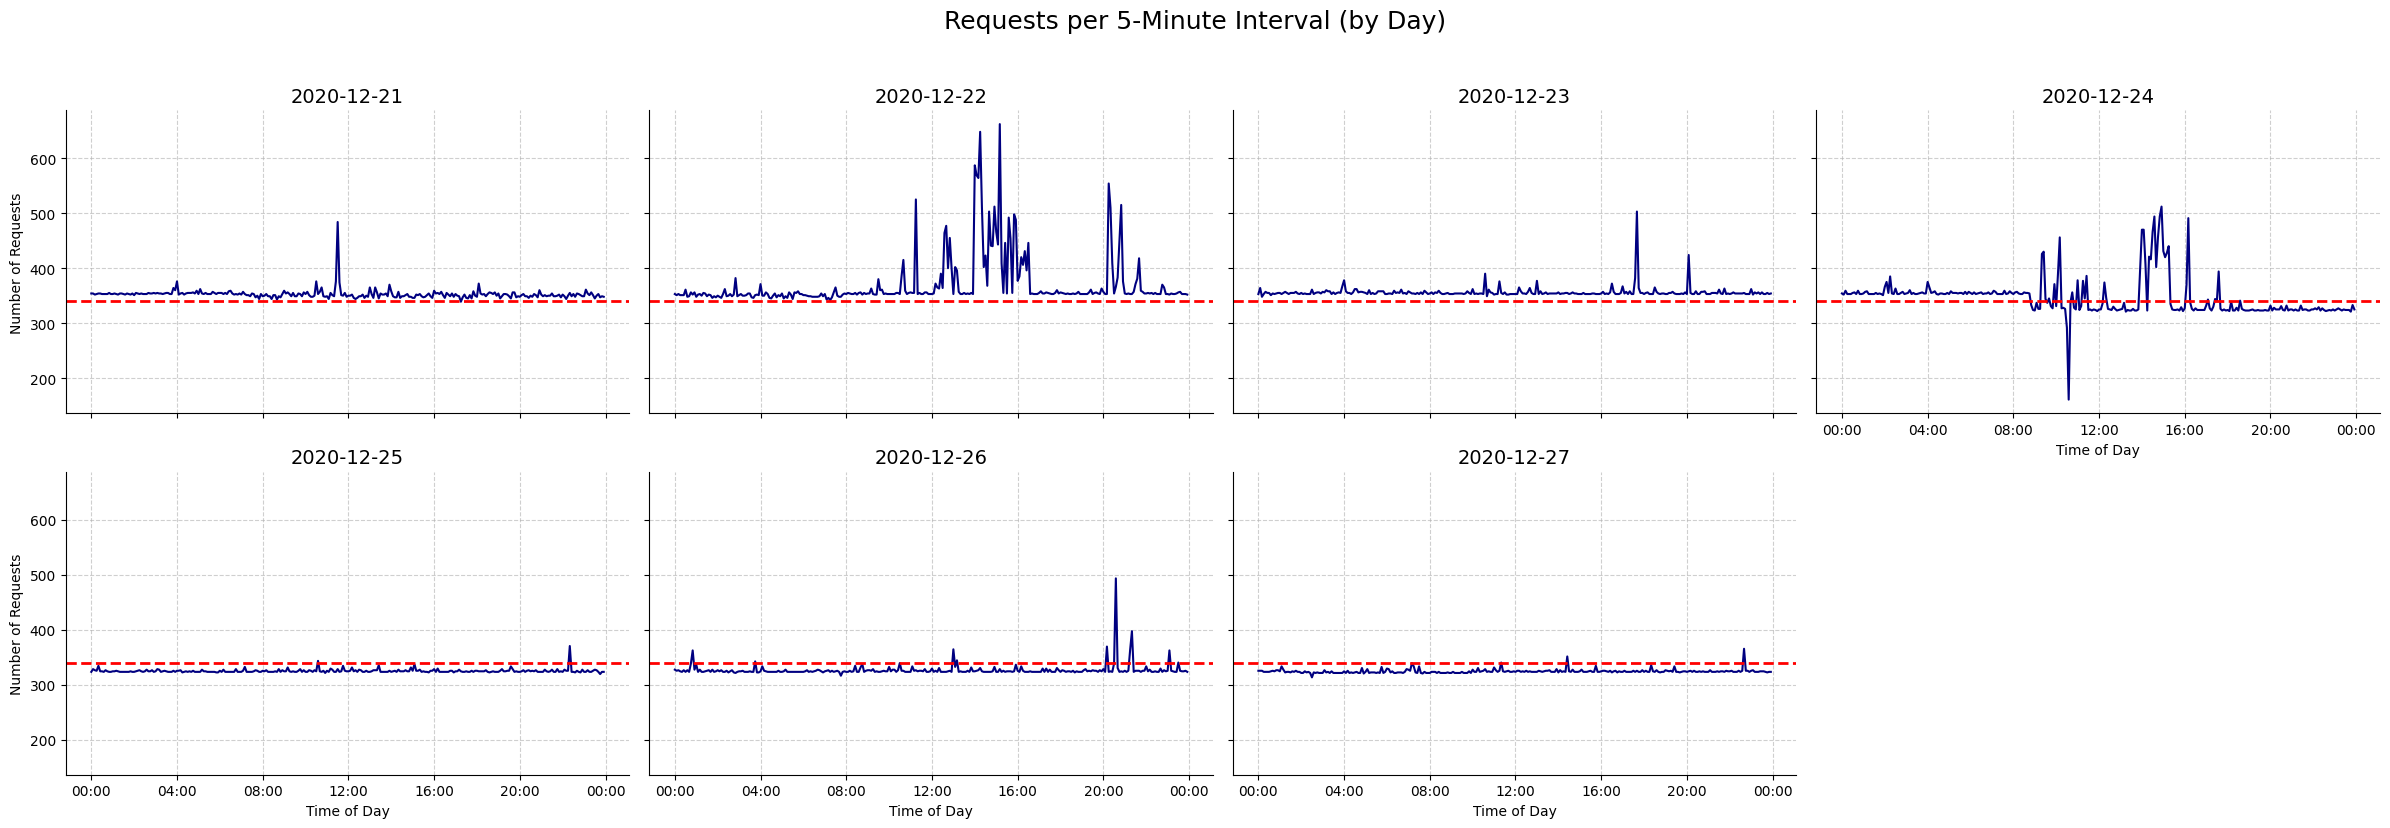

In [ ]:
print_traffic_for_days(df_agg)

In [ ]:
df_cleaned["source.ip"].n_unique()

617

In [ ]:
requests_per_ip = df_cleaned.group_by("source.ip").agg(
    pl.len().alias("request_count")).sort("request_count", descending=True)

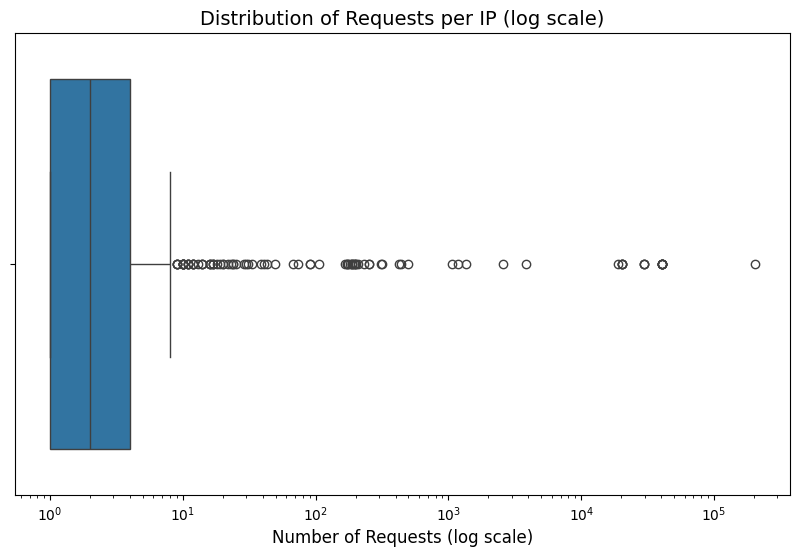

In [ ]:
# Step 1: Convert to Pandas
requests_per_ip_pd = requests_per_ip.to_pandas()

# Create boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=requests_per_ip_pd["request_count"])
plt.xscale("log")  # logarithmic scale
plt.title("Distribution of Requests per IP (log scale)", fontsize=14)
plt.xlabel("Number of Requests (log scale)", fontsize=12)
plt.show()

In [ ]:
daily_median_stats = df_agg.group_by("day").agg(
    pl.col("len").median().alias("median_requests_per_5min")
).with_columns(
    pl.col("day").str.to_date().dt.strftime("%A").alias("day_of_week")
).sort("day")

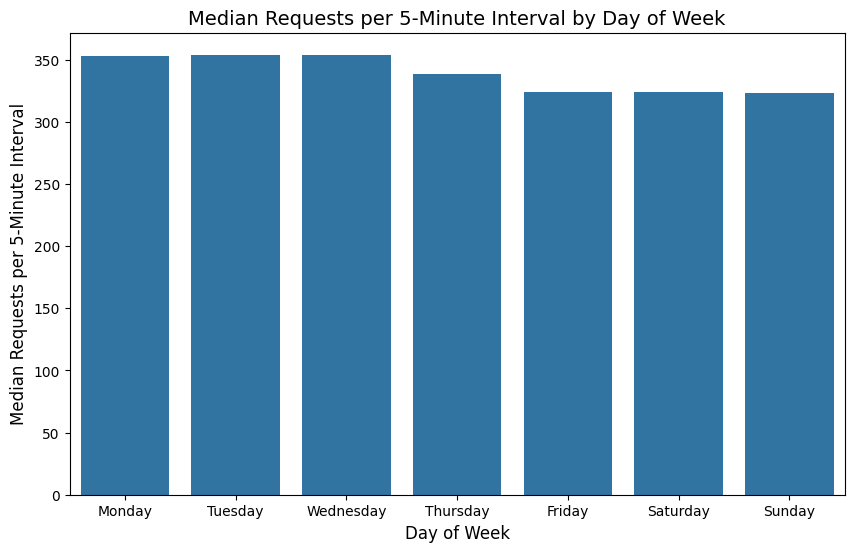

In [ ]:
daily_median_pd = daily_median_stats.to_pandas()

# Optional: order days of week properly
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(10, 6))
sns.barplot(
    x="day_of_week",
    y="median_requests_per_5min",
    data=daily_median_pd,
    order=day_order
)
plt.title("Median Requests per 5-Minute Interval by Day of Week", fontsize=14)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Median Requests per 5-Minute Interval", fontsize=12)
plt.show()

Generating new line plot...


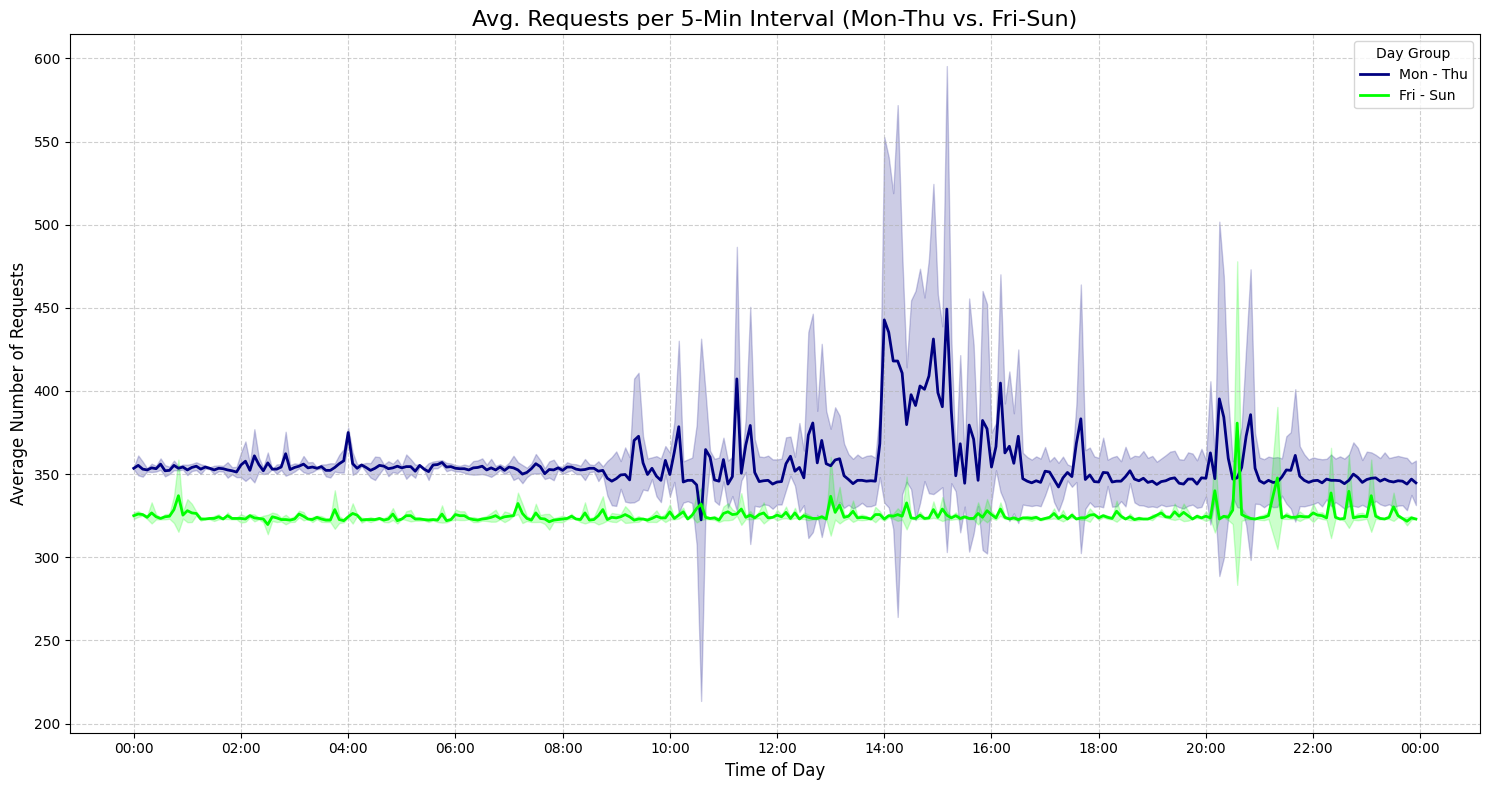

In [ ]:
df_with_daygroup = df_agg.with_columns(
    pl.col("day").str.to_date()
).with_columns(
    pl.when(pl.col("day").dt.weekday().is_in([5, 6, 7])) # 5=Fri, 6=Sat, 7=Sun
    .then(pl.lit("Fri - Sun"))
    .otherwise(pl.lit("Mon - Thu"))
    .alias("day_group")
)

df_pd = df_with_daygroup.to_pandas()

dummy_date = dt.date(dt.now())
df_pd['plot_time'] = df_pd['time_bin'].apply(lambda t: dt.combine(dummy_date, t))


print("Generating new line plot...")

plt.figure(figsize=(15, 8))

sns.lineplot(
    data=df_pd,
    x="plot_time",
    y="len",
    hue="day_group",    # Use the new 'day_group' column
    errorbar="sd",        # Show standard deviation
    palette={"Mon - Thu": "navy", "Fri - Sun": "lime"}, # Update palette labels
    linewidth=2
)


plt.title('Avg. Requests per 5-Min Interval (Mon-Thu vs. Fri-Sun)', fontsize=16) # Updated title
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Average Number of Requests', fontsize=12)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.legend(title='Day Group')

plt.tight_layout()
plt.savefig("plots/mon-thu_vs_fri-sun_plot.png")

## Analysis for 2 groups: Mon - Thu, Fri - Sun

In [ ]:
df_grouped_agg = df_agg.with_columns(
    pl.col("day").str.to_date()  # Convert back to date object
).with_columns(
    pl.when(pl.col("day").dt.weekday().is_in([5, 6, 7])) # 5=Fri, 6=Sat, 7=Sun
    .then(pl.lit(1))
    .otherwise(pl.lit(0))
    .alias("weekend")
)

In [ ]:
df_grouped_agg.head()

day,time_bin,len,weekend
date,time,u32,i32
2020-12-21,00:00:00,354,0
2020-12-21,00:05:00,354,0
2020-12-21,00:10:00,352,0
2020-12-21,00:15:00,353,0
2020-12-21,00:20:00,354,0


In [ ]:
# 1. Calculate the mean and std dev for each group
stats_zscore = df_grouped_agg.group_by("weekend").agg(
    pl.col("len").mean().alias("mean"),
    pl.col("len").std().alias("std_dev")
)

print("--- Z-score Stats ---")
print(stats_zscore)

# 2. Join stats back and calculate Z-score for each 5-min bin
df_with_zscore = df_grouped_agg.join(stats_zscore, on="weekend").with_columns(
    ((pl.col("len") - pl.col("mean")) / pl.col("std_dev")).alias("z_score")
)

# 3. Filter for outliers (a Z-score > 3 is a common threshold)
outliers_zscore = df_with_zscore.filter(
    (pl.col("z_score") > 3.0) | (pl.col("z_score") < -3.0)
).sort("z_score", descending=True)

print(f"\nFound {len(outliers_zscore)} outliers using Z-score > 3.")
print(outliers_zscore.head())

--- Z-score Stats ---
shape: (2, 3)
┌─────────┬────────────┬───────────┐
│ weekend ┆ mean       ┆ std_dev   │
│ ---     ┆ ---        ┆ ---       │
│ i32     ┆ f64        ┆ f64       │
╞═════════╪════════════╪═══════════╡
│ 0       ┆ 356.523438 ┆ 31.615431 │
│ 1       ┆ 324.988426 ┆ 7.846284  │
└─────────┴────────────┴───────────┘

Found 42 outliers using Z-score > 3.
shape: (5, 7)
┌────────────┬──────────┬─────┬─────────┬────────────┬───────────┬───────────┐
│ day        ┆ time_bin ┆ len ┆ weekend ┆ mean       ┆ std_dev   ┆ z_score   │
│ ---        ┆ ---      ┆ --- ┆ ---     ┆ ---        ┆ ---       ┆ ---       │
│ date       ┆ time     ┆ u32 ┆ i32     ┆ f64        ┆ f64       ┆ f64       │
╞════════════╪══════════╪═════╪═════════╪════════════╪═══════════╪═══════════╡
│ 2020-12-26 ┆ 20:35:00 ┆ 493 ┆ 1       ┆ 324.988426 ┆ 7.846284  ┆ 21.412884 │
│ 2020-12-22 ┆ 15:10:00 ┆ 662 ┆ 0       ┆ 356.523438 ┆ 31.615431 ┆ 9.662261  │
│ 2020-12-22 ┆ 14:15:00 ┆ 648 ┆ 0       ┆ 356.523438 ┆ 31.61543

Generating outlier scatterplot...
Plot saved as 'outlier_scatterplot.png'
Plot saved as 'mon-thu_vs_fri-sun_plot.png'


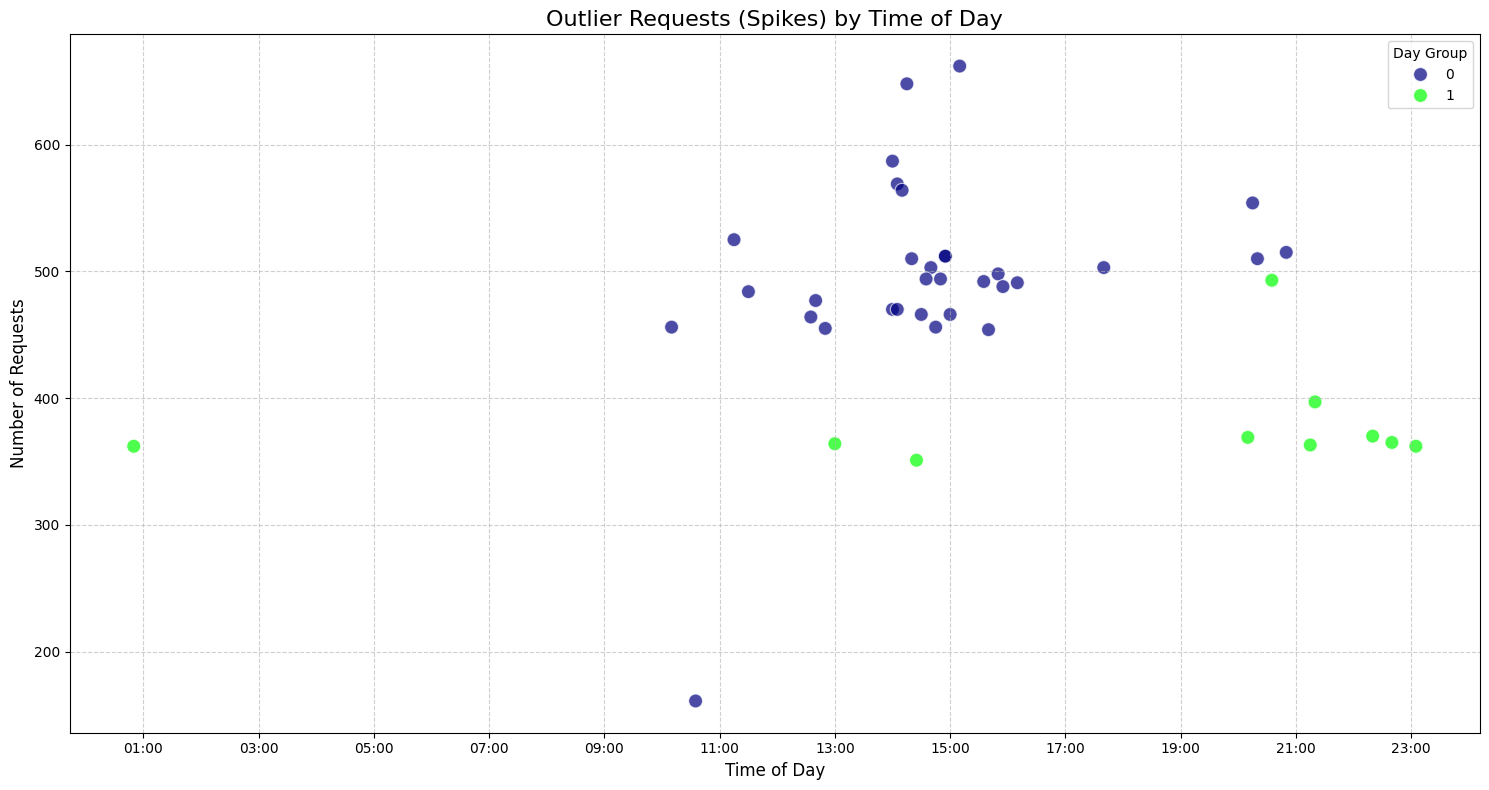

In [ ]:
df_pd_outliers = outliers_zscore.to_pandas()

# --- 2. Apply Plotting Fix ---
# Combine time_bin with a dummy date
dummy_date = dt.date(dt.now())
df_pd_outliers['plot_time'] = df_pd_outliers['time_bin'].apply(lambda t: dt.combine(dummy_date, t))

# --- 3. Plotting with Seaborn ---
print("Generating outlier scatterplot...")

plt.figure(figsize=(15, 8))

sns.scatterplot(
    data=df_pd_outliers,
    x="plot_time",
    y="len",
    hue="weekend",    # Color points by 'Mon-Thu' or 'Fri-Sun'
    palette={0: "navy", 1: "lime"}, # Match previous plot
    s=100,              # Set dot size
    alpha=0.7           # Set transparency
)

# --- 4. Customize and Save ---
plt.title('Outlier Requests (Spikes) by Time of Day', fontsize=16)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)

# Format the x-axis to show time as "HH:MM"
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.legend(title='Day Group')

plt.tight_layout()
plt.savefig("outlier_scatterplot.png")

print("Plot saved as 'outlier_scatterplot.png'")
print("Plot saved as 'mon-thu_vs_fri-sun_plot.png'")

In [ ]:
# 1. Calculate a rolling median (baseline) for each day
# We'll use a 1,5-hour window (18 * 5-min bins)
# We use .over("day") to calculate the rolling window separately for each day
window_size = 12 
df_with_rolling = df_grouped_agg.with_columns(
    pl.col("len").rolling_median(
        window_size=window_size, 
        center=True, # Center the window for a smoother baseline
        min_samples=1
    ).over("day").alias("baseline") # 'over' is like a group_by for window functions
)

# We'll look for points that are, for example, 30% larger than the baseline
threshold_pct = 0.30  

outliers_rolling = df_with_rolling.filter(
    ((pl.col("len") - pl.col("baseline")) / pl.col("baseline") > threshold_pct) | (pl.col("len") < pl.col("baseline") * (1 - threshold_pct))
).sort("len", descending=True)

print(f"\nFound {len(outliers_rolling)} outliers using {threshold_pct:.0%} deviation from rolling baseline.")
print(outliers_rolling.head())


Found 16 outliers using 30% deviation from rolling baseline.
shape: (5, 5)
┌────────────┬──────────┬─────┬─────────┬──────────┐
│ day        ┆ time_bin ┆ len ┆ weekend ┆ baseline │
│ ---        ┆ ---      ┆ --- ┆ ---     ┆ ---      │
│ date       ┆ time     ┆ u32 ┆ i32     ┆ f64      │
╞════════════╪══════════╪═════╪═════════╪══════════╡
│ 2020-12-22 ┆ 15:10:00 ┆ 662 ┆ 0       ┆ 444.5    │
│ 2020-12-22 ┆ 14:15:00 ┆ 648 ┆ 0       ┆ 463.0    │
│ 2020-12-22 ┆ 14:00:00 ┆ 587 ┆ 0       ┆ 378.5    │
│ 2020-12-22 ┆ 14:05:00 ┆ 569 ┆ 0       ┆ 412.5    │
│ 2020-12-22 ┆ 14:10:00 ┆ 564 ┆ 0       ┆ 412.5    │
└────────────┴──────────┴─────┴─────────┴──────────┘


In [ ]:
df_with_rolling.head(3)

day,time_bin,len,weekend,baseline
date,time,u32,i32,f64
2020-12-21,00:00:00,354,0,354.0
2020-12-21,00:05:00,354,0,354.0
2020-12-21,00:10:00,352,0,353.5


Generating outlier scatterplot...
Plot saved as 'outlier_scatterplot.png'
Plot saved as 'mon-thu_vs_fri-sun_plot.png'


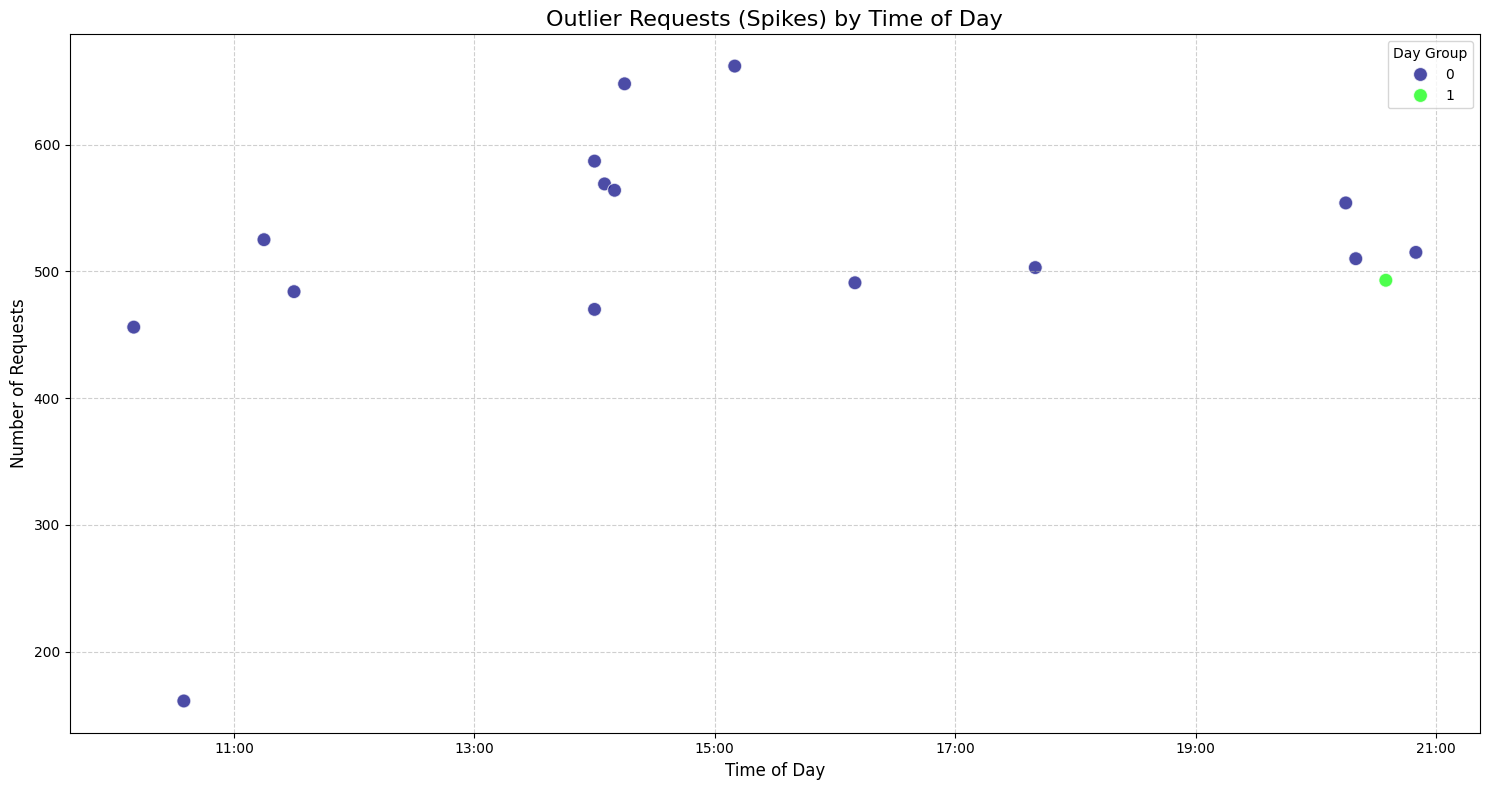

In [ ]:
df_pd_outliers = outliers_rolling.to_pandas()

# --- 2. Apply Plotting Fix ---
# Combine time_bin with a dummy date
dummy_date = dt.date(dt.now())
df_pd_outliers['plot_time'] = df_pd_outliers['time_bin'].apply(lambda t: dt.combine(dummy_date, t))

# --- 3. Plotting with Seaborn ---
print("Generating outlier scatterplot...")

plt.figure(figsize=(15, 8))

sns.scatterplot(
    data=df_pd_outliers,
    x="plot_time",
    y="len",
    hue="weekend",    # Color points by 'Mon-Thu' or 'Fri-Sun'
    palette={0: "navy", 1: "lime"}, # Match previous plot
    s=100,              # Set dot size
    alpha=0.7           # Set transparency
)

# --- 4. Customize and Save ---
plt.title('Outlier Requests (Spikes) by Time of Day', fontsize=16)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)

# Format the x-axis to show time as "HH:MM"
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.legend(title='Day Group')

plt.tight_layout()
plt.savefig("outlier_scatterplot.png")

print("Plot saved as 'outlier_scatterplot.png'")
print("Plot saved as 'mon-thu_vs_fri-sun_plot.png'")

In [ ]:
outliers_rolling.head(3)

day,time_bin,len,weekend,baseline
date,time,u32,i32,f64
2020-12-22,15:10:00,662,0,444.5
2020-12-22,14:15:00,648,0,463.0
2020-12-22,14:00:00,587,0,378.5


# Analysis of outliers

In [ ]:
# 1. Add the 'day' and 'time_bin' columns (this was correct)
df_with_bins = df_cleaned.lazy().with_columns(
    pl.col("timestamp").dt.date().alias("day"),
    pl.col("timestamp").dt.truncate("5m").dt.time().alias("time_bin")
)

# 2. Use .join() with how="semi"
df_outlier_logs = df_with_bins.join(
    outliers_rolling.lazy(),     # This is your filter
    on=["day", "time_bin"],
    how="semi"            # Specify the join type here
).collect() # .collect() executes the query and gives us the final DataFrame

# 3. (Optional) You can drop the temporary 'day' and 'time_bin' columns
df_outlier_logs = df_outlier_logs.drop(["day", "time_bin"])

print(f"Successfully isolated {len(df_outlier_logs):,} original log records from the outlier periods!")
print(df_outlier_logs.head())

Successfully isolated 8,192 original log records from the outlier periods!
shape: (5, 21)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ timestamp ┆ source.ip ┆ source.re ┆ source.as ┆ … ┆ agent.id  ┆ tags      ┆ correlati ┆ geo_code │
│ ---       ┆ ---       ┆ gistered_ ┆ ---       ┆   ┆ ---       ┆ ---       ┆ on        ┆ ---      │
│ datetime[ ┆ str       ┆ domain    ┆ struct[2] ┆   ┆ str       ┆ list[str] ┆ ---       ┆ str      │
│ ms]       ┆           ┆ ---       ┆           ┆   ┆           ┆           ┆ struct[1] ┆          │
│           ┆           ┆ str       ┆           ┆   ┆           ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2020-12-2 ┆ 172.18.0. ┆ securely- ┆ {"Private ┆ … ┆ ad99edda- ┆ ["beats_i ┆ {[]}      ┆ unknown  │
│ 1         ┆ 2         ┆ app_elk   ┆ -Use",nul ┆   ┆ a068-4794 ┆ nput_code ┆           ┆          │
│

In [ ]:
df_outlier_logs.shape

(8192, 21)

In [ ]:
method_counts = df_outlier_logs["http.request.method"].value_counts()
total_count = method_counts["count"].sum()
dist_outlier_logs = method_counts.with_columns(
    (pl.col("count") / total_count * 100).alias("percentage")
)

print(dist_outlier_logs)

shape: (6, 3)
┌─────────────────────┬───────┬────────────┐
│ http.request.method ┆ count ┆ percentage │
│ ---                 ┆ ---   ┆ ---        │
│ str                 ┆ u32   ┆ f64        │
╞═════════════════════╪═══════╪════════════╡
│ POST                ┆ 2491  ┆ 30.407715  │
│ GET                 ┆ 5074  ┆ 61.938477  │
│ PUT                 ┆ 123   ┆ 1.501465   │
│ DELETE              ┆ 3     ┆ 0.036621   │
│ PATCH               ┆ 191   ┆ 2.331543   │
│ HEAD                ┆ 310   ┆ 3.78418    │
└─────────────────────┴───────┴────────────┘


In [ ]:
counts_all = df_cleaned.get_column("http.request.method").value_counts()
counts_outlier = df_outlier_logs.get_column("http.request.method").value_counts()

counts_all = counts_all.rename({"count": "count_all"})
counts_outlier = counts_outlier.rename({"count": "count_outlier"})

# Join the counts together using an outer join
contingency_df = counts_all.join(
    counts_outlier, 
    on="http.request.method", 
    how="full"
).fill_null(0) 

print("--- Contingency Table Data ---")
print(contingency_df)

observed_counts = contingency_df.select(["count_all", "count_outlier"]).to_numpy()


chi2, p_value, dof, expected = chi2_contingency(observed_counts)

print("\n--- Chi-squared Test Results ---")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-value:        {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

# --- 4. Interpretation ---
alpha = 0.05  # Standard significance level
if p_value < alpha:
    print(f"\nConclusion: Since p-value ({p_value:.4f}) < {alpha}, we reject the null hypothesis.")
    print("The distribution of HTTP methods is significantly DIFFERENT between outlier logs and all logs.")


--- Contingency Table Data ---
shape: (7, 4)
┌─────────────────────┬───────────┬───────────────────────────┬───────────────┐
│ http.request.method ┆ count_all ┆ http.request.method_right ┆ count_outlier │
│ ---                 ┆ ---       ┆ ---                       ┆ ---           │
│ str                 ┆ u32       ┆ str                       ┆ u32           │
╞═════════════════════╪═══════════╪═══════════════════════════╪═══════════════╡
│ POST                ┆ 204676    ┆ POST                      ┆ 2491          │
│ DELETE              ┆ 6         ┆ DELETE                    ┆ 3             │
│ PUT                 ┆ 568       ┆ PUT                       ┆ 123           │
│ HEAD                ┆ 4590      ┆ HEAD                      ┆ 310           │
│ OPTIONS             ┆ 1         ┆ null                      ┆ 0             │
│ GET                 ┆ 480933    ┆ GET                       ┆ 5074          │
│ PATCH               ┆ 731       ┆ PATCH                     ┆ 191        